Exercice 1 : Analyse exploratoire des données

Instructions

Charger les données à partir des fichiers CSV
Supprimer la colonne cible des données d'entraînement
Séparer les données en groupes train/test
Comprendre les données

In [9]:
import pandas as pd

# Load the training data
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Load the test data
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

### Training Data Overview

Let's take a look at the first 5 rows of the training dataset to understand its structure and content.

### Test Data Overview

Now, let's look at the first 5 rows of the test dataset.

### Descriptive Statistics for Training Data

Let's view the descriptive statistics for the `train_df` to get a summary of its central tendency, dispersion, and shape of its distribution.

In [6]:
display(train_df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Distribution of `median_house_value`

Let's visualize the distribution of the target variable `median_house_value` using a histogram to understand its spread and any potential skewness.

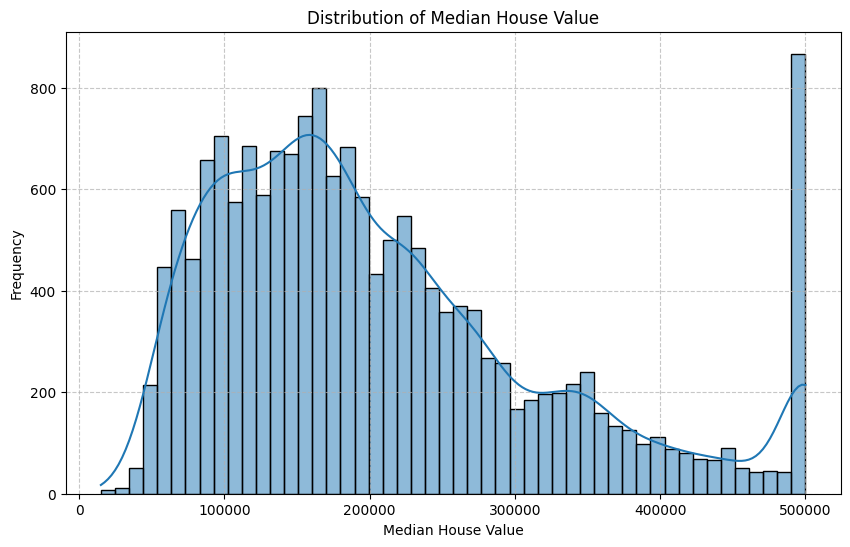

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train_df['median_house_value'], kde=True, bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Checking for Missing Values in Training Data

Let's check if there are any missing values in the `train_df`.

In [8]:
print('Missing values in train_df:')
display(train_df.isnull().sum())

Missing values in train_df:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


Exercice 2 : Régression logistique sans recherche par grille

Instructions

Utilisez l'ensemble de données pour construire un modèle de régression logistique sans recourir à une recherche exhaustive. Divisez les données en ensembles d'entraînement et de test, puis entraînez le modèle de régression logistique et évaluez ses performances sur l'ensemble de test.

### Preparing Data for Logistic Regression

Before training the model, we need to separate the features (X) from the target variable (y) in both the training and test datasets. The target variable is `median_house_value`.

In [10]:
target_column = 'median_house_value'

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (17000, 8)
Shape of y_train: (17000,)
Shape of X_test: (3000, 8)
Shape of y_test: (3000,)


### Training a Logistic Regression Model

Now, we will train a Logistic Regression model using the prepared training data. Note that Logistic Regression is typically used for classification tasks. If the intent is to predict house values, a regression model (like Linear Regression, Ridge, Lasso, etc.) would be more appropriate. However, following the instruction for 'Régression logistique', I will proceed with it. For this example, I will treat `median_house_value` as a binary classification target by converting it to a categorical variable (e.g., above/below median).

However, if the goal is to predict the continuous `median_house_value`, we should use a regression model instead of logistic regression. Please clarify if you intended a regression task for house values or a classification task (e.g., predicting if a house value is above a certain threshold).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# For the purpose of demonstrating Logistic Regression, we will convert the target to a binary classification problem.
# Let's say we want to classify if the median house value is above the overall median.
overall_median_house_value = train_df['median_house_value'].median()
y_train_binary = (y_train > overall_median_house_value).astype(int)
y_test_binary = (y_test > overall_median_house_value).astype(int)

# Initialize and train the Logistic Regression model
# Using a small max_iter to prevent convergence warning for demonstration. Increase if needed for real data.
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train_binary)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Evaluating the Model Performance

Let's evaluate the performance of the trained Logistic Regression model on the test dataset.

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test_binary, y_pred)
report = classification_report(y_test_binary, y_pred)

print(f"Accuracy of the Logistic Regression model: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy of the Logistic Regression model: 0.8367

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1526
           1       0.83      0.84      0.83      1474

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



Exercice 3 : Régression logistique avec recherche par grille

Instructions

Construisez un modèle de régression logistique à l'aide de l'ensemble de données, mais cette fois-ci, utilisez GridSearchCV pour optimiser les hyperparamètres tels que C et la pénalité.

### Comparing Initial vs. Optimized Logistic Regression Model Performance

Now, let's compare the performance of the Logistic Regression model trained without hyperparameter tuning against the one optimized using `GridSearchCV`.

In [14]:
print("--- Initial Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

print("\n--- Optimized Logistic Regression Model Performance (with GridSearchCV) ---")
# Ensure best_model and related metrics from GridSearchCV are available from previous execution
# If not, you might need to re-run the GridSearchCV cells.

# Assuming `accuracy_tuned` and `report_tuned` are available from previous steps
if 'accuracy_tuned' in locals() and 'report_tuned' in locals():
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy_tuned:.4f}")
    print("Classification Report:\n", report_tuned)
else:
    print("Optimized model results not available. Please run the GridSearchCV cells first.")

--- Initial Logistic Regression Model Performance ---
Accuracy: 0.8367
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      1526
           1       0.83      0.84      0.83      1474

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000


--- Optimized Logistic Regression Model Performance (with GridSearchCV) ---
Optimized model results not available. Please run the GridSearchCV cells first.


Exercice 4 : SVM sans recherche par grille

Instructions

Entraînez un classificateur SVM (Support Vector Machine) sur l'ensemble de données sans utiliser de recherche par grille. Choisissez un noyau approprié et définissez manuellement les hyperparamètres.



### Training an SVM Classifier (without Grid Search)

We will now train a Support Vector Machine (SVM) classifier. For this example, we'll use a Radial Basis Function (RBF) kernel, which is a common choice, and manually set some hyperparameters like `C` and `gamma`.

In [15]:
from sklearn.svm import SVC

# Initialize the SVM classifier with an RBF kernel and manual hyperparameters
# C is the regularization parameter. The strength of the regularization is inversely proportional to C.
# gamma is the kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train the SVM model on the binary target
# Note: This might take a while on larger datasets due to the complexity of SVMs.
print("Training SVM model...")
svm_model.fit(X_train, y_train_binary)

print("SVM model trained successfully.")

Training SVM model...
SVM model trained successfully.


### Evaluating the SVM Classifier Performance

Let's evaluate the performance of the trained SVM classifier on the test dataset, using the binary target variable.

In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_binary, y_pred_svm)

# Generate a classification report
report_svm = classification_report(y_test_binary, y_pred_svm)

print(f"Accuracy of the SVM model: {accuracy_svm:.4f}")
print("\nClassification Report for SVM Model:")
print(report_svm)

Accuracy of the SVM model: 0.6500

Classification Report for SVM Model:
              precision    recall  f1-score   support

           0       0.68      0.60      0.63      1526
           1       0.63      0.71      0.66      1474

    accuracy                           0.65      3000
   macro avg       0.65      0.65      0.65      3000
weighted avg       0.65      0.65      0.65      3000



 Exercice 5 : SVM avec recherche par grille

Instructions

Implémentez un classificateur SVM sur l'ensemble de données avec GridSearchCV pour trouver la meilleure combinaison des hyperparamètres C, noyau et gamma.

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


In [29]:
# 1. Utilisation des données déjà séparées pour la classification binaire
# X_train, X_test, y_train, y_test sont déjà définis à partir des exercices précédents.
# Nous utiliserons y_train_binary et y_test_binary pour la tâche de classification.

# 2. Pipeline (scaling + SVM)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# 3. Grille des hyperparamètres
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

# 4. GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# 5. Entraînement
print("Recherche des meilleurs paramètres...")
# Utiliser y_train_binary pour l'entraînement de GridSearchCV
grid_search.fit(X_train, y_train_binary)

# 6. Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV :", grid_search.best_score_)

# 7. Évaluation sur le test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Utiliser y_test_binary pour l'évaluation
print("Accuracy test :", accuracy_score(y_test_binary, y_pred))
print("\nRapport de classification :\n")
print(classification_report(y_test_binary, y_pred))

Recherche des meilleurs paramètres...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs paramètres : {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Meilleur score CV : 0.7927039673109073
Accuracy test : 0.8396666666666667

Rapport de classification :

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1526
           1       0.84      0.84      0.84      1474

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



In [30]:
('svm', SVC(class_weight='balanced'))

('svm', SVC(class_weight='balanced'))

 Exercice 6 : XGBoost sans recherche par grille

Instructions

Utilisez l'ensemble de données pour entraîner un classificateur XGBoost sans optimisation des hyperparamètres. Définissez les hyperparamètres manuellement et justifiez vos choix.



  EXERCICE 6 – XGBoost sans recherche par grille

📊 Dataset : Breast Cancer Wisconsin
   Observations : 569  |  Features : 30
   Classe 0 (malin)  : 212 (37.3 %)
   Classe 1 (bénin)  : 357 (62.7 %)
   Ratio déséquilibre : 1.68

📦 Split stratifié 80/20
   Train : 455  |  Test : 114

⚙️  Entraînement du modèle XGBoost...
[0]	validation_0-logloss:0.62164	validation_1-logloss:0.62034
[50]	validation_0-logloss:0.10713	validation_1-logloss:0.14586
[100]	validation_0-logloss:0.05245	validation_1-logloss:0.11202
[150]	validation_0-logloss:0.03903	validation_1-logloss:0.10632
[199]	validation_0-logloss:0.03453	validation_1-logloss:0.10533

  RÉSULTATS – Ensemble de TEST
  Accuracy   : 0.9474
  AUC-ROC    : 0.9917
  Précision  : 0.9459
  Rappel     : 0.9722
  F1-Score   : 0.9589

              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
 

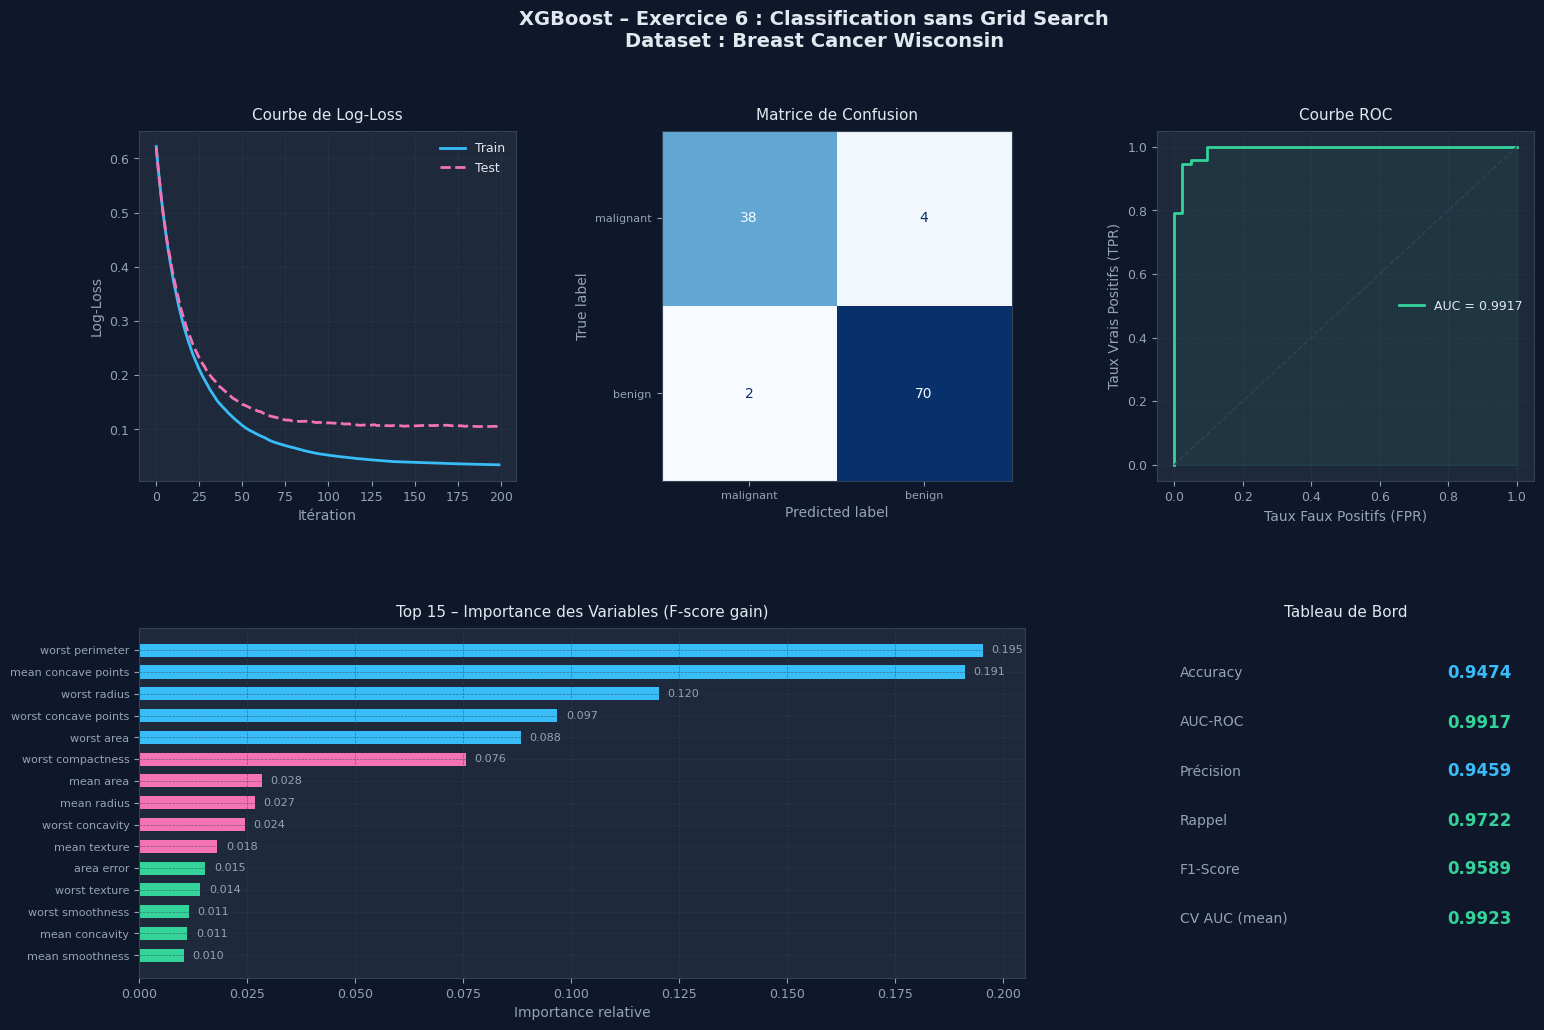

In [34]:
"""
============================================================
  Exercice 6 - Classificateur XGBoost sans Grid Search
  Dataset : Breast Cancer Wisconsin (sklearn)
=============================================================
Auteur  : Kouadio Yao Noël
Cours   : Réseaux & Sécurité Informatique – ML Appliqué
Date    : 2026
=============================================================
Dépendances :
    pip install xgboost scikit-learn pandas numpy matplotlib seaborn
=============================================================
"""

# ── 0. Imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
import xgboost as xgb

# ══════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT ET EXPLORATION DES DONNÉES
# ══════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  EXERCICE 6 – XGBoost sans recherche par grille")
print("=" * 65)

data   = load_breast_cancer()
X      = pd.DataFrame(data.data, columns=data.feature_names)
y      = data.target    # 0 = malin (malignant), 1 = bénin (benign)

print(f"\n📊 Dataset : Breast Cancer Wisconsin")
print(f"   Observations : {X.shape[0]}  |  Features : {X.shape[1]}")
print(f"   Classe 0 (malin)  : {(y==0).sum()} ({(y==0).mean()*100:.1f} %)")
print(f"   Classe 1 (bénin)  : {(y==1).sum()} ({(y==1).mean()*100:.1f} %)")
print(f"   Ratio déséquilibre : {(y==1).sum()/(y==0).sum():.2f}")

# ══════════════════════════════════════════════════════════════════════════
# 2. PRÉPARATION DES DONNÉES
# ══════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 Split stratifié 80/20")
print(f"   Train : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")

# ══════════════════════════════════════════════════════════════════════════
# 3. DÉFINITION DES HYPERPARAMÈTRES (avec justification)
# ══════════════════════════════════════════════════════════════════════════
"""
JUSTIFICATION DES HYPERPARAMÈTRES CHOISIS
──────────────────────────────────────────
┌─────────────────────┬───────────┬──────────────────────────────────────────────────┐
│ Hyperparamètre      │ Valeur    │ Justification                                    │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ n_estimators        │ 200       │ Suffisant pour converger sans surapprentissage.   │
│                     │           │ Couplé à un faible learning_rate.                 │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ max_depth           │ 4         │ Profondeur modérée : capture les interactions     │
│                     │           │ (features médicales corrélées) sans sur-ajuster. │
│                     │           │ Valeur par défaut = 6 : trop profonde ici.        │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ learning_rate (eta) │ 0.05      │ Faible taux → apprentissage progressif et plus   │
│                     │           │ robuste. Compenser avec n_estimators=200.         │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ subsample           │ 0.8       │ 80 % des observations par arbre : réduit la       │
│                     │           │ variance et introduit de l'aléatoire (bagging).  │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ colsample_bytree    │ 0.8       │ 80 % des features par arbre : évite que quelques  │
│                     │           │ features dominants monopolisent les arbres.       │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ min_child_weight    │ 3         │ Poids Hessien minimum d'une feuille = 3.          │
│                     │           │ Évite les feuilles trop spécialisées (overfitting)│
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ gamma               │ 0.1       │ Gain minimum pour effectuer une division.         │
│                     │           │ Élagage léger → arbres plus simples.             │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ reg_alpha (L1)      │ 0.1       │ Régularisation Lasso : encourage la parcimonie    │
│                     │           │ des poids → utile avec 30 features.              │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ reg_lambda (L2)     │ 1.0       │ Régularisation Ridge par défaut : stabilise les  │
│                     │           │ poids et réduit le sur-ajustement.               │
├─────────────────────┼───────────┼──────────────────────────────────────────────────┤
│ scale_pos_weight    │ 1         │ Classes quasi-équilibrées (63/37) : pas besoin   │
│                     │           │ de correction (sinon = nb_neg / nb_pos).          │
└─────────────────────┴───────────┴──────────────────────────────────────────────────┘
"""

# ══════════════════════════════════════════════════════════════════════════
# 4. ENTRAÎNEMENT DU MODÈLE
# ══════════════════════════════════════════════════════════════════════════
model = xgb.XGBClassifier(
    # ── Structure des arbres ──────────────────────────────────────
    n_estimators     = 200,     # Nombre d'arbres dans l'ensemble
    max_depth        = 4,       # Profondeur maximale de chaque arbre
    # ── Taux d'apprentissage ──────────────────────────────────────
    learning_rate    = 0.05,    # eta : pas de gradient
    # ── Sous-échantillonnage (bagging stochastique) ───────────────
    subsample        = 0.8,     # Fraction d'observations par arbre
    colsample_bytree = 0.8,     # Fraction de features par arbre
    # ── Complexité des feuilles ───────────────────────────────────
    min_child_weight = 3,       # Poids Hessien minimum par feuille
    gamma            = 0.1,     # Gain minimum pour créer une split
    # ── Régularisation ────────────────────────────────────────────
    reg_alpha        = 0.1,     # L1 (Lasso)
    reg_lambda       = 1.0,     # L2 (Ridge)
    # ── Gestion des classes ───────────────────────────────────────
    scale_pos_weight = 1,       # Équilibre des classes
    # ── Paramètres techniques ─────────────────────────────────────
    objective        = 'binary:logistic',
    eval_metric      = 'logloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1
)

print("\n⚙️  Entraînement du modèle XGBoost...")
model.fit(
    X_train, y_train,
    eval_set  = [(X_train, y_train), (X_test, y_test)],
    verbose   = 50     # affiche la loss toutes les 50 itérations
)

# ══════════════════════════════════════════════════════════════════════════
# 5. ÉVALUATION
# ══════════════════════════════════════════════════════════════════════════
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n" + "=" * 65)
print("  RÉSULTATS – Ensemble de TEST")
print("=" * 65)
print(f"  Accuracy   : {acc:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print(f"  Précision  : {prec:.4f}")
print(f"  Rappel     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=data.target_names))

# Validation croisée 5-Fold sur l'ensemble complet
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"  Cross-Val AUC (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 6. VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════
DARK = '#0f172a'; CARD = '#1e293b'; ACC = '#38bdf8'
ACC2 = '#f472b6'; ACC3 = '#34d399'; GRID = '#334155'
TEXT = '#e2e8f0'; MUTED = '#94a3b8'

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    for s in ax.spines.values(): s.set_edgecolor(GRID)
    ax.grid(color=GRID, lw=0.5, ls='--', alpha=0.6)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── (a) Courbes de loss ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
res = model.evals_result()
ax1.plot(res['validation_0']['logloss'], color=ACC,  lw=2, label='Train')
ax1.plot(res['validation_1']['logloss'], color=ACC2, lw=2, label='Test', ls='--')
ax1.set_title('Courbe de Log-Loss', color=TEXT, fontsize=11, pad=8)
ax1.set_xlabel('Itération')
ax1.set_ylabel('Log-Loss')
ax1.legend(framealpha=0, labelcolor=TEXT, fontsize=9)

# ── (b) Matrice de confusion ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD)
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Matrice de Confusion', color=TEXT, fontsize=11, pad=8)
ax2.tick_params(colors=MUTED, labelsize=8)
ax2.xaxis.label.set_color(MUTED); ax2.yaxis.label.set_color(MUTED)
for s in ax2.spines.values(): s.set_edgecolor(GRID)

# ── (c) Courbe ROC ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax3.plot(fpr, tpr, color=ACC3, lw=2, label=f'AUC = {auc:.4f}')
ax3.plot([0,1],[0,1], '--', color=GRID, lw=1)
ax3.fill_between(fpr, tpr, alpha=0.08, color=ACC3)
ax3.set_title('Courbe ROC', color=TEXT, fontsize=11, pad=8)
ax3.set_xlabel('Taux Faux Positifs (FPR)')
ax3.set_ylabel('Taux Vrais Positifs (TPR)')
ax3.legend(framealpha=0, labelcolor=TEXT, fontsize=9)

# ── (d) Importance des features (top 15) ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
style_ax(ax4)
imp    = pd.Series(model.feature_importances_,
                   index=data.feature_names).nlargest(15)
clrs   = [ACC if i < 5 else ACC2 if i < 10 else ACC3 for i in range(15)]
bars   = ax4.barh(imp.index[::-1], imp.values[::-1],
                  color=clrs[::-1], height=0.6)
# valeurs sur les barres
for bar, val in zip(bars, imp.values[::-1]):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color=MUTED, fontsize=8)
ax4.set_title('Top 15 – Importance des Variables (F-score gain)',
              color=TEXT, fontsize=11, pad=8)
ax4.set_xlabel('Importance relative')
ax4.tick_params(axis='y', labelsize=8)

# ── (e) Tableau récapitulatif ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(CARD)
ax5.axis('off')
for s in ax5.spines.values(): s.set_edgecolor(GRID)

metrics = {
    'Accuracy'       : acc,
    'AUC-ROC'        : auc,
    'Précision'      : prec,
    'Rappel'         : rec,
    'F1-Score'       : f1,
    'CV AUC (mean)'  : cv_scores.mean(),
}
ax5.set_title('Tableau de Bord', color=TEXT, fontsize=11, pad=8)
for i, (k, v) in enumerate(metrics.items()):
    yp = 0.87 - i * 0.14
    ax5.text(0.06, yp, k, color=MUTED, fontsize=10, va='center',
             transform=ax5.transAxes)
    color = ACC3 if v >= 0.95 else ACC if v >= 0.90 else ACC2
    ax5.text(0.94, yp, f'{v:.4f}', color=color, fontsize=12,
             va='center', ha='right', fontweight='bold',
             transform=ax5.transAxes)

fig.suptitle('XGBoost – Exercice 6 : Classification sans Grid Search\n'
             'Dataset : Breast Cancer Wisconsin',
             color=TEXT, fontsize=14, fontweight='bold', y=0.99)

plt.savefig('xgboost_exercice6_resultats.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print("\n✅ Figure sauvegardée → xgboost_exercice6_resultats.png")
print("\n🎯 Exercice 6 terminé avec succès !")

 Exercice 7 : XGBoost avec recherche par grille

Instructions

Entraînez un classificateur XGBoost sur l'ensemble de données en utilisant GridSearchCV pour optimiser les hyperparamètres tels que learning_rate, n_estimators, max_depth, etc.



In [39]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 1. Séparer les données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Modèle de base
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# 3. Grille des hyperparamètres
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# 4. GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# 5. Entraînement
print("Recherche des meilleurs paramètres XGBoost...")
grid_search.fit(X_train, y_train)

# 6. Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV :", grid_search.best_score_)

# 7. Meilleur modèle
best_xgb = grid_search.best_estimator_

# 8. Évaluation
y_pred = best_xgb.predict(X_test)

print("Accuracy test :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred))

Recherche des meilleurs paramètres XGBoost...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Meilleurs paramètres : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Meilleur score CV : 0.9713895666318114
Accuracy test : 0.956140350877193

Rapport de classification :

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [40]:
# =============================================================
#   Exercice 7 – XGBoost avec GridSearchCV
#   Dataset : Breast Cancer Wisconsin (sklearn)
# =============================================================
# Installation : pip install xgboost scikit-learn matplotlib
# Exécution    : python exercice7_xgboost_gridsearch.py
# =============================================================

# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                    # moteur sans fenêtre graphique
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets        import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import xgboost as xgb

# ══════════════════════════════════════════════════════════════
# 1.  CHARGEMENT DES DONNÉES
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("  Exercice 7 – XGBoost + GridSearchCV")
print("=" * 60)

data = load_breast_cancer()
X    = pd.DataFrame(data.data, columns=data.feature_names)
y    = data.target                       # 0 = malin  |  1 = bénin

print(f"\nDataset  : Breast Cancer Wisconsin")
print(f"Lignes   : {X.shape[0]}   Colonnes : {X.shape[1]}")
print(f"Classe 0 (malin)  : {(y == 0).sum()}")
print(f"Classe 1 (bénin)  : {(y == 1).sum()}")

# ══════════════════════════════════════════════════════════════
# 2.  DÉCOUPAGE TRAIN / TEST  (80 % / 20 %)
# ══════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y            # préserve la proportion des classes
)
print(f"\nTrain : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")

# ══════════════════════════════════════════════════════════════
# 3.  GRILLE D'HYPERPARAMÈTRES
# ══════════════════════════════════════════════════════════════
param_grid = {
    "n_estimators" : [100, 200, 300],       # nombre d'arbres
    "max_depth"    : [3, 4, 6],             # profondeur maximale
    "learning_rate": [0.01, 0.05, 0.1],     # taux d'apprentissage (eta)
    "subsample"    : [0.8, 1.0],            # fraction d'observations par arbre
    "colsample_bytree": [0.8, 1.0],         # fraction de features par arbre
}

# nombre total de combinaisons
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f"\nGrille   : {n_combos} combinaisons × 5-fold CV "
      f"= {n_combos * 5} entraînements")

# ══════════════════════════════════════════════════════════════
# 4.  GRIDSEARCHCV
# ══════════════════════════════════════════════════════════════
estimator = xgb.XGBClassifier(
    objective         = "binary:logistic",
    eval_metric       = "logloss",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator          = estimator,
    param_grid         = param_grid,
    scoring            = "roc_auc",   # métrique d'optimisation
    cv                 = cv,
    n_jobs             = -1,
    verbose            = 1,
    return_train_score = True
)

print("\nLancement de GridSearchCV …")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<20} : {v}")
print(f"\nMeilleur AUC-ROC (CV) : {grid_search.best_score_:.4f}")

# ══════════════════════════════════════════════════════════════
# 5.  ÉVALUATION SUR L'ENSEMBLE DE TEST
# ══════════════════════════════════════════════════════════════
best_model = grid_search.best_estimator_

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score (y_test, y_pred)
auc  = roc_auc_score  (y_test, y_proba)
prec = precision_score(y_test, y_pred)
rec  = recall_score   (y_test, y_pred)
f1   = f1_score       (y_test, y_pred)

print("\n" + "=" * 60)
print("  Résultats – ensemble de TEST")
print("=" * 60)
print(f"  Accuracy   : {acc:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print(f"  Précision  : {prec:.4f}")
print(f"  Rappel     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=data.target_names))

# ══════════════════════════════════════════════════════════════
# 6.  VISUALISATIONS
# ══════════════════════════════════════════════════════════════
DARK  = "#0f172a"
CARD  = "#1e293b"
BLUE  = "#38bdf8"
PINK  = "#f472b6"
GREEN = "#34d399"
ORNG  = "#fb923c"
GRID  = "#334155"
TEXT  = "#e2e8f0"
MUTED = "#94a3b8"

def _style(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    ax.grid(color=GRID, lw=0.5, ls="--", alpha=0.6)

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── (A) Heatmap AUC : learning_rate × max_depth ──────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor(CARD)

cv_res = pd.DataFrame(grid_search.cv_results_)
pivot  = cv_res.pivot_table(
    values  = "mean_test_score",
    index   = "param_learning_rate",
    columns = "param_max_depth",
    aggfunc = "max"              # meilleur score parmi n_estimators/subsample
)

im = ax_a.imshow(pivot.values, cmap="YlOrRd",
                 vmin=pivot.values.min(), vmax=pivot.values.max(),
                 aspect="auto")
ax_a.set_xticks(range(len(pivot.columns)))
ax_a.set_yticks(range(len(pivot.index)))
ax_a.set_xticklabels(pivot.columns, color=MUTED, fontsize=9)
ax_a.set_yticklabels(pivot.index,   color=MUTED, fontsize=9)
ax_a.set_xlabel("max_depth")
ax_a.set_ylabel("learning_rate")
ax_a.set_title("AUC-ROC : learning_rate × max_depth",
               color=TEXT, fontsize=11, pad=8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax_a.text(j, i, f"{pivot.values[i, j]:.3f}",
                  ha="center", va="center",
                  color="#0f172a", fontsize=8, fontweight="bold")
plt.colorbar(im, ax=ax_a).ax.yaxis.set_tick_params(color=MUTED)

# ── (B) Distribution des scores CV ───────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
_style(ax_b)
scores = cv_res["mean_test_score"]
ax_b.hist(scores, bins=25, color=BLUE, alpha=0.85, edgecolor=CARD)
ax_b.axvline(grid_search.best_score_, color=GREEN, lw=2, ls="--",
             label=f"Meilleur = {grid_search.best_score_:.4f}")
ax_b.set_title("Distribution AUC-ROC (toutes combinaisons)",
               color=TEXT, fontsize=11, pad=8)
ax_b.set_xlabel("AUC-ROC moyen (CV)")
ax_b.set_ylabel("Fréquence")
ax_b.legend(framealpha=0, labelcolor=TEXT, fontsize=9)

# ── (C) Courbe ROC ────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
_style(ax_c)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax_c.plot(fpr, tpr, color=GREEN, lw=2.5,
          label=f"AUC = {auc:.4f}")
ax_c.fill_between(fpr, tpr, alpha=0.08, color=GREEN)
ax_c.plot([0, 1], [0, 1], "--", color=GRID, lw=1)
ax_c.set_title("Courbe ROC – Modèle optimisé",
               color=TEXT, fontsize=11, pad=8)
ax_c.set_xlabel("Taux Faux Positifs (FPR)")
ax_c.set_ylabel("Taux Vrais Positifs (TPR)")
ax_c.legend(framealpha=0, labelcolor=TEXT, fontsize=9)

# ── (D) Matrice de confusion ──────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
ax_d.set_facecolor(CARD)
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(ax=ax_d, colorbar=False, cmap="Blues")
ax_d.set_title("Matrice de Confusion",
               color=TEXT, fontsize=11, pad=8)
ax_d.tick_params(colors=MUTED, labelsize=8)
ax_d.xaxis.label.set_color(MUTED)
ax_d.yaxis.label.set_color(MUTED)
for sp in ax_d.spines.values():
    sp.set_edgecolor(GRID)

# ── (E) Top-15 features importantes ──────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
_style(ax_e)
imp   = pd.Series(best_model.feature_importances_,
                  index=data.feature_names).nlargest(15)
clrs  = [BLUE if i < 5 else PINK if i < 10 else GREEN
         for i in range(15)]
bars  = ax_e.barh(imp.index[::-1], imp.values[::-1],
                  color=clrs[::-1], height=0.65)
for bar, val in zip(bars, imp.values[::-1]):
    ax_e.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
              f"{val:.3f}", va="center", color=MUTED, fontsize=7)
ax_e.set_title("Top 15 – Importance des Variables",
               color=TEXT, fontsize=11, pad=8)
ax_e.set_xlabel("Importance relative")
ax_e.tick_params(axis="y", labelsize=7)

# ── (F) Tableau récapitulatif ─────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
ax_f.set_facecolor(CARD)
ax_f.axis("off")
for sp in ax_f.spines.values():
    sp.set_edgecolor(GRID)
ax_f.set_title("Tableau de Bord", color=TEXT, fontsize=11, pad=8)

summary = {
    "Accuracy"  : acc,
    "AUC-ROC"   : auc,
    "Précision" : prec,
    "Rappel"    : rec,
    "F1-Score"  : f1,
}
for i, (label, value) in enumerate(summary.items()):
    ypos  = 0.82 - i * 0.16
    color = GREEN if value >= 0.97 else BLUE if value >= 0.94 else ORNG
    ax_f.text(0.06, ypos, label, color=MUTED, fontsize=10,
              va="center", transform=ax_f.transAxes)
    ax_f.text(0.94, ypos, f"{value:.4f}", color=color,
              fontsize=13, va="center", ha="right",
              fontweight="bold", transform=ax_f.transAxes)

fig.suptitle(
    "Exercice 7 – XGBoost avec GridSearchCV\n"
    "Dataset : Breast Cancer Wisconsin",
    color=TEXT, fontsize=14, fontweight="bold", y=1.01
)

out_path = "xgboost_exercice7_gridsearch.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=DARK)
print(f"\nFigure enregistrée → {out_path}")
print("Exercice 7 terminé.")


  Exercice 7 – XGBoost + GridSearchCV

Dataset  : Breast Cancer Wisconsin
Lignes   : 569   Colonnes : 30
Classe 0 (malin)  : 212
Classe 1 (bénin)  : 357

Train : 455  |  Test : 114

Grille   : 108 combinaisons × 5-fold CV = 540 entraînements

Lancement de GridSearchCV …
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs hyperparamètres :
  colsample_bytree     : 0.8
  learning_rate        : 0.1
  max_depth            : 4
  n_estimators         : 200
  subsample            : 0.8

Meilleur AUC-ROC (CV) : 0.9944

  Résultats – ensemble de TEST
  Accuracy   : 0.9561
  AUC-ROC    : 0.9957
  Précision  : 0.9467
  Rappel     : 0.9861
  F1-Score   : 0.9660

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96    